In [ ]:
!pip install torch torchvision timm mediapipe opencv-python numpy scipy scikit-learn pillow
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/fatigue_project


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: '/content/drive/MyDrive/fatigue_project'
/content


In [ ]:
!mkdir -p data/physical/nthu_ddd/normal
!mkdir -p data/physical/nthu_ddd/fatigued
!mkdir -p data/physical/yawdd/normal
!mkdir -p data/physical/yawdd/fatigued
!mkdir -p data/mental/stroop/pre_task
!mkdir -p data/mental/stroop/post_task


In [ ]:
!pip install kaggle gdown
!mkdir -p ~/.kaggle


In [ ]:
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd -p /content/data/physical/ddd
!unzip -q /content/data/physical/ddd/driver-drowsiness-dataset-ddd.zip -d /content/data/physical/ddd


Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
100% 2.57G/2.58G [00:43<00:00, 229MB/s]
100% 2.58G/2.58G [00:43<00:00, 63.7MB/s]


In [ ]:
!kaggle datasets download -d enider/yawdd-dataset -p /content/data/physical/yawdd
!unzip -q /content/data/physical/yawdd/yawdd-dataset.zip -d /content/data/physical/yawdd


Dataset URL: https://www.kaggle.com/datasets/enider/yawdd-dataset
License(s): MIT
100% 5.08G/5.08G [00:21<00:00, 196MB/s]
100% 5.08G/5.08G [00:21<00:00, 256MB/s]


In [ ]:
!git clone https://github.com/zykev/facial_fatigue.git /content/data/mental/facial_fatigue


Cloning into '/content/data/mental/facial_fatigue'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 155 (delta 83), reused 107 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 20.86 MiB | 19.52 MiB/s, done.
Resolving deltas: 100% (83/83), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/fatigue_data


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Mount Google Drive (re-mount if needed)
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/fatigue_data"

print("\n📁 Checking dataset structure under:", base_path)
print("="*70)

def check_dataset(path, name):
    total_files = sum(len(files) for _, _, files in os.walk(path))
    total_size = sum(os.path.getsize(os.path.join(root, f))
                     for root, _, files in os.walk(path) for f in files)
    size_mb = round(total_size / (1024*1024), 2)
    print(f"{name:<35} → {total_files:>6} files | {size_mb:>7} MB")

# Physical datasets
check_dataset(f"{base_path}/physical/ddd", "Driver Drowsiness (DDD)")
check_dataset(f"{base_path}/physical/yawdd", "YAWDD (Yawning)")
# Mental dataset
check_dataset(f"{base_path}/mental/facial_fatigue", "Facial Fatigue (LFD)")

print("="*70)
print("✅  If you see non-zero file counts & sizes above, all data is safe in Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📁 Checking dataset structure under: /content/drive/MyDrive/fatigue_data
Driver Drowsiness (DDD)             →      0 files |     0.0 MB
YAWDD (Yawning)                     →      0 files |     0.0 MB
Facial Fatigue (LFD)                →      0 files |     0.0 MB
✅  If you see non-zero file counts & sizes above, all data is safe in Drive!


In [ ]:
!mkdir -p /content/drive/MyDrive/fatigue_data/physical/ddd
!mkdir -p /content/drive/MyDrive/fatigue_data/physical/yawdd
!mkdir -p /content/drive/MyDrive/fatigue_data/mental/facial_fatigue



In [ ]:
!cp -r /content/data/physical/ddd/* /content/drive/MyDrive/fatigue_data/physical/ddd/ 2>/dev/null || true
!cp -r /content/data/physical/yawdd/* /content/drive/MyDrive/fatigue_data/physical/yawdd/ 2>/dev/null || true
!cp -r /content/data/mental/facial_fatigue/* /content/drive/MyDrive/fatigue_data/mental/facial_fatigue/ 2>/dev/null || true


In [ ]:
import os
base_path = "/content/drive/MyDrive/fatigue_data"
for path in [
    f"{base_path}/physical/ddd",
    f"{base_path}/physical/yawdd",
    f"{base_path}/mental/facial_fatigue"
]:
    total_files = sum(len(files) for _, _, files in os.walk(path))
    print(path, "→", total_files, "files")


/content/drive/MyDrive/fatigue_data/physical/ddd → 41794 files
/content/drive/MyDrive/fatigue_data/physical/yawdd → 352 files
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue → 44 files


In [ ]:
import torch
print(torch.cuda.is_available())


True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install mediapipe opencv-python tqdm
import cv2, mediapipe as mp, os, numpy as np, pandas as pd
from tqdm import tqdm
from pathlib import Path


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


In [ ]:
base_path = "/content/drive/MyDrive/fatigue_data"

# Input folders
ddd_path = f"{base_path}/physical/ddd"
yawdd_path = f"{base_path}/physical/yawdd"
facial_fatigue_path = f"{base_path}/mental/facial_fatigue"

# Output folders for extracted frames/features
output_root = f"{base_path}/processed_frames"
Path(output_root).mkdir(parents=True, exist_ok=True)


In [ ]:
mp_face = mp.solutions.face_mesh

def extract_landmarks(image):
    with mp_face.FaceMesh(static_image_mode=True,
                          max_num_faces=1,
                          refine_landmarks=True,
                          min_detection_confidence=0.5) as face_mesh:
        results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks:
            return None
        landmarks = results.multi_face_landmarks[0].landmark
        coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
        return coords


In [ ]:
def process_video(video_path, label, save_dir, sample_rate=5):
    cap = cv2.VideoCapture(video_path)
    frames, count = [], 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if count % sample_rate == 0:
            frame = cv2.resize(frame, (224,224))
            landmarks = extract_landmarks(frame)
            if landmarks is not None:
                frames.append(landmarks)
        count += 1
    cap.release()
    if frames:
        frames = np.array(frames)
        np.save(f"{save_dir}/{Path(video_path).stem}_{label}.npy", frames)


processing datasets

In [ ]:
for dataset_path, label in [(ddd_path, "fatigued"), (yawdd_path, "fatigued")]:
    save_dir = f"{output_root}/physical"
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    video_files = list(Path(dataset_path).rglob("*.mp4"))
    print(f"Processing {len(video_files)} videos from {dataset_path}")
    for v in tqdm(video_files[:20]):   # limit for demo / quick test
        process_video(str(v), label, save_dir)


Processing 0 videos from /content/drive/MyDrive/fatigue_data/physical/ddd


0it [00:00, ?it/s]


Processing 0 videos from /content/drive/MyDrive/fatigue_data/physical/yawdd


0it [00:00, ?it/s]


In [ ]:
def process_images(folder_path, label, save_dir):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    img_files = list(Path(folder_path).rglob("*.jpg")) + list(Path(folder_path).rglob("*.png"))
    print(f"Processing {len(img_files)} images from {folder_path}")
    for img_path in tqdm(img_files[:200]):   # sample subset for now
        img = cv2.imread(str(img_path))
        img = cv2.resize(img, (224,224))
        landmarks = extract_landmarks(img)
        if landmarks is not None:
            np.save(f"{save_dir}/{Path(img_path).stem}_{label}.npy", landmarks)

process_images(facial_fatigue_path, "mental_fatigued", f"{output_root}/mental")


Processing 0 images from /content/drive/MyDrive/fatigue_data/mental/facial_fatigue


0it [00:00, ?it/s]


In [ ]:
!find /content/drive/MyDrive/fatigue_data/processed_frames -type f | wc -l


0


In [ ]:
from pathlib import Path

base_paths = [
    "/content/drive/MyDrive/fatigue_data/physical/ddd",
    "/content/drive/MyDrive/fatigue_data/physical/yawdd"
]

for base in base_paths:
    print(f"\n🔍 Searching inside: {base}")
    mp4_files = list(Path(base).rglob("*.mp4"))
    avi_files = list(Path(base).rglob("*.avi"))
    print(f"Found {len(mp4_files)} mp4 and {len(avi_files)} avi files")
    if mp4_files:
        print("Example mp4:", mp4_files[0])
    if avi_files:
        print("Example avi:", avi_files[0])



🔍 Searching inside: /content/drive/MyDrive/fatigue_data/physical/ddd
Found 0 mp4 and 0 avi files

🔍 Searching inside: /content/drive/MyDrive/fatigue_data/physical/yawdd
Found 0 mp4 and 0 avi files


In [ ]:
# Kaggle setup (if not done)
!pip install kaggle
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Create Drive folders
!mkdir -p /content/drive/MyDrive/fatigue_data/physical/ddd
!mkdir -p /content/drive/MyDrive/fatigue_data/physical/yawdd
!mkdir -p /content/drive/MyDrive/fatigue_data/mental/facial_fatigue

# Download DDD
!kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd -p /content/drive/MyDrive/fatigue_data/physical/ddd
!unzip -q /content/drive/MyDrive/fatigue_data/physical/ddd/driver-drowsiness-dataset-ddd.zip -d /content/drive/MyDrive/fatigue_data/physical/ddd

# Download YAWDD
!kaggle datasets download -d enider/yawdd-dataset -p /content/drive/MyDrive/fatigue_data/physical/yawdd
!unzip -q /content/drive/MyDrive/fatigue_data/physical/yawdd/yawdd-dataset.zip -d /content/drive/MyDrive/fatigue_data/physical/yawdd

# Clone Facial_Fatigue repo (GitHub)
!git clone https://github.com/zykev/facial_fatigue.git /content/drive/MyDrive/fatigue_data/mental/facial_fatigue


Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
 99% 2.56G/2.58G [00:17<00:00, 163MB/s]
100% 2.58G/2.58G [00:17<00:00, 161MB/s]
Dataset URL: https://www.kaggle.com/datasets/enider/yawdd-dataset
License(s): MIT
100% 5.08G/5.08G [00:46<00:00, 185MB/s]
100% 5.08G/5.08G [00:46<00:00, 117MB/s]
fatal: destination path '/content/drive/MyDrive/fatigue_data/mental/facial_fatigue' already exists and is not an empty directory.


In [ ]:
!ls /content/drive/MyDrive/fatigue_data/physical/ddd | head
!ls /content/drive/MyDrive/fatigue_data/physical/yawdd | head
!ls /content/drive/MyDrive/fatigue_data/mental/facial_fatigue | head


Driver Drowsiness Dataset (DDD)
driver-drowsiness-dataset-ddd.zip
Dash
Mirror
Readme_YawDD.pdf
Table1.pdf
Table2.pdf
yawdd-dataset.zip
acc_analysis.py
Code
Code_tomse2
comScript_cha.py
Data
drawTools.py
face_align.py
gradcam4face_class.py
gradcam_class.py
Images


In [ ]:
from pathlib import Path

for base in [
    "/content/drive/MyDrive/fatigue_data/physical/ddd",
    "/content/drive/MyDrive/fatigue_data/physical/yawdd",
    "/content/drive/MyDrive/fatigue_data/mental/facial_fatigue"
]:
    files = list(Path(base).rglob("*.*"))
    print(f"{base} → {len(files)} files")



/content/drive/MyDrive/fatigue_data/physical/ddd → 41794 files
/content/drive/MyDrive/fatigue_data/physical/yawdd → 352 files
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue → 68 files


In [ ]:
!pip install mediapipe opencv-python tqdm


In [ ]:
import cv2, mediapipe as mp, os, numpy as np, pandas as pd
from tqdm import tqdm
from pathlib import Path


In [ ]:
base_path = "/content/drive/MyDrive/fatigue_data"

# Input folders
ddd_path = f"{base_path}/physical/ddd"
yawdd_path = f"{base_path}/physical/yawdd"
facial_fatigue_path = f"{base_path}/mental/facial_fatigue"

# Output folders for extracted frames/features
output_root = f"{base_path}/processed_frames"
Path(output_root).mkdir(parents=True, exist_ok=True)


In [ ]:
mp_face = mp.solutions.face_mesh

def extract_landmarks(image):
    with mp_face.FaceMesh(static_image_mode=True,
                          max_num_faces=1,
                          refine_landmarks=True,
                          min_detection_confidence=0.5) as face_mesh:
        results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks:
            return None
        landmarks = results.multi_face_landmarks[0].landmark
        coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
        return coords


In [ ]:
def process_video(video_path, label, save_dir, sample_rate=5):
    cap = cv2.VideoCapture(video_path)
    frames, count = [], 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if count % sample_rate == 0:
            frame = cv2.resize(frame, (224,224))
            landmarks = extract_landmarks(frame)
            if landmarks is not None:
                frames.append(landmarks)
        count += 1
    cap.release()
    if frames:
        frames = np.array(frames)
        np.save(f"{save_dir}/{Path(video_path).stem}_{label}.npy", frames)


In [ ]:
for dataset_path, label in [(ddd_path, "fatigued"), (yawdd_path, "fatigued")]:
    save_dir = f"{output_root}/physical"
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    video_files = list(Path(dataset_path).rglob("*.mp4"))
    print(f"Processing {len(video_files)} videos from {dataset_path}")
    for v in tqdm(video_files[:20]):   # limit for demo / quick test
        process_video(str(v), label, save_dir)


Processing 0 videos from /content/drive/MyDrive/fatigue_data/physical/ddd


0it [00:00, ?it/s]


Processing 0 videos from /content/drive/MyDrive/fatigue_data/physical/yawdd


0it [00:00, ?it/s]


In [ ]:
!pip install mediapipe opencv-python tqdm numpy


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from pathlib import Path
from tqdm import tqdm
import os


In [ ]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False,
                                  max_num_faces=1,
                                  refine_landmarks=True,
                                  min_detection_confidence=0.5,
                                  min_tracking_confidence=0.5)


In [ ]:
def extract_face_features(frame):
    """
    Detects 3D face landmarks and returns a flattened feature vector.
    """
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(frame_rgb)
    if not results.multi_face_landmarks:
        return None

    landmarks = results.multi_face_landmarks[0].landmark
    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
    return coords


In [ ]:
def process_video_folder(input_dir, output_dir, frame_skip=10):
    os.makedirs(output_dir, exist_ok=True)
    video_files = list(Path(input_dir).rglob("*.mp4")) + list(Path(input_dir).rglob("*.avi"))
    print(f"🎥 Found {len(video_files)} videos in {input_dir}")

    for video_path in tqdm(video_files, desc=f"Processing {Path(input_dir).name}"):
        cap = cv2.VideoCapture(str(video_path))
        features = []
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx % frame_skip == 0:
                feat = extract_face_features(frame)
                if feat is not None:
                    features.append(feat)
            frame_idx += 1
        cap.release()

        if features:
            features = np.stack(features)
            np.save(Path(output_dir) / f"{video_path.stem}.npy", features)

    print(f"✅ Saved features to: {output_dir}")


In [ ]:
def process_image_folder(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    image_files = list(Path(input_dir).rglob("*.jpg")) + list(Path(input_dir).rglob("*.png"))
    print(f"🖼️ Found {len(image_files)} images in {input_dir}")

    for img_path in tqdm(image_files, desc=f"Processing {Path(input_dir).name}"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        feat = extract_face_features(img)
        if feat is not None:
            np.save(Path(output_dir) / f"{img_path.stem}.npy", feat)

    print(f"✅ Saved facial fatigue features to: {output_dir}")


In [ ]:
# Base input paths (already verified)
ddd_path = "/content/drive/MyDrive/fatigue_data/physical/ddd"
yawdd_path = "/content/drive/MyDrive/fatigue_data/physical/yawdd"
facial_path = "/content/drive/MyDrive/fatigue_data/mental/facial_fatigue"

# Output dirs for processed .npy files
out_ddd = "/content/drive/MyDrive/fatigue_data/processed_frames/ddd"
out_yawdd = "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd"
out_facial = "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"

process_video_folder(ddd_path, out_ddd)
process_video_folder(yawdd_path, out_yawdd)
process_image_folder(facial_path, out_facial)


🎥 Found 0 videos in /content/drive/MyDrive/fatigue_data/physical/ddd


Processing ddd: 0it [00:00, ?it/s]

✅ Saved features to: /content/drive/MyDrive/fatigue_data/processed_frames/ddd


🎥 Found 348 videos in /content/drive/MyDrive/fatigue_data/physical/yawdd


Processing yawdd: 100%|██████████| 348/348 [08:00<00:00,  1.38s/it]


✅ Saved features to: /content/drive/MyDrive/fatigue_data/processed_frames/yawdd
🖼️ Found 3 images in /content/drive/MyDrive/fatigue_data/mental/facial_fatigue


Processing facial_fatigue: 100%|██████████| 3/3 [00:00<00:00, 20.69it/s]

✅ Saved facial fatigue features to: /content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue


In [ ]:
!find /content/drive/MyDrive/fatigue_data/physical/ddd -type f | head -20


/content/drive/MyDrive/fatigue_data/physical/ddd/driver-drowsiness-dataset-ddd.zip
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0001.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0002.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0003.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0004.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0005.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0006.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0007.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0008.png
/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy/A0009.png
/content/drive/MyDrive/fatigue_data

In [ ]:
# Corrected path for DDD (it has images)
ddd_images_path = "/content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy"
out_ddd = "/content/drive/MyDrive/fatigue_data/processed_frames/ddd"

# Reuse the same helper you already have
process_image_folder(ddd_images_path, out_ddd)


🖼️ Found 22348 images in /content/drive/MyDrive/fatigue_data/physical/ddd/Driver Drowsiness Dataset (DDD)/Drowsy


Processing Drowsy: 100%|██████████| 22348/22348 [12:50<00:00, 28.99it/s]


✅ Saved facial fatigue features to: /content/drive/MyDrive/fatigue_data/processed_frames/ddd


In [ ]:
from pathlib import Path

ddd_npy = list(Path("/content/drive/MyDrive/fatigue_data/processed_frames/ddd").rglob("*.npy"))
print(f"✅ Total DDD feature files: {len(ddd_npy)}")
print("🔹 Example files:", ddd_npy[:5])


✅ Total DDD feature files: 22347
🔹 Example files: [PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/ddd/A0001.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/ddd/A0002.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/ddd/A0003.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/ddd/A0004.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/ddd/A0005.npy')]


In [ ]:
from pathlib import Path

for base in [
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
]:
    print(f"{base} → {len(list(Path(base).rglob('*.npy')))} files")


/content/drive/MyDrive/fatigue_data/processed_frames/ddd → 22347 files
/content/drive/MyDrive/fatigue_data/processed_frames/yawdd → 348 files
/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue → 0 files


In [ ]:
!find /content/drive/MyDrive/fatigue_data/mental/facial_fatigue -type f | head -10


/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/update.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/push-to-checkout.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/post-update.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/applypatch-msg.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/pre-merge-commit.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/pre-push.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/pre-rebase.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/fsmonitor-watchman.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/prepare-commit-msg.sample
/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/.git/hooks/pre-applypatch.sample


In [ ]:
!pip install kaggle -q

!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download FER2013 dataset
!kaggle datasets download -d msambare/fer2013 -p /content/drive/MyDrive/fatigue_data/mental/facial_fatigue
!unzip -q /content/drive/MyDrive/fatigue_data/mental/facial_fatigue/fer2013.zip -d /content/drive/MyDrive/fatigue_data/mental/facial_fatigue


Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
 40% 24.0M/60.3M [00:00<00:00, 250MB/s]
100% 60.3M/60.3M [00:00<00:00, 316MB/s]


In [ ]:
!ls /content/drive/MyDrive/fatigue_data/mental/facial_fatigue


acc_analysis.py   face_align.py		 readme.md
Code		  fer2013.zip		 test
Code_tomse2	  gradcam4face_class.py  train
comScript_cha.py  gradcam_class.py	 Train_FrameAttention.py
Data		  Images		 Train_FrameAttention_tomse2.py
drawTools.py	  model			 vidaug


In [ ]:
import os, shutil
from pathlib import Path

src_base = "/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/train"
dst_fatigued = "/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/fatigued"
dst_nonfatigued = "/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/non_fatigued"

os.makedirs(dst_fatigued, exist_ok=True)
os.makedirs(dst_nonfatigued, exist_ok=True)

# Move images by class
for cls in Path(src_base).iterdir():
    if cls.name.lower() in ["neutral", "sad"]:
        for img in cls.glob("*.jpg"):
            shutil.copy(img, dst_fatigued)
    else:
        for img in cls.glob("*.jpg"):
            shutil.copy(img, dst_nonfatigued)

print("Fatigued:", len(list(Path(dst_fatigued).rglob("*.jpg"))),
      "| Non-fatigued:", len(list(Path(dst_nonfatigued).rglob("*.jpg"))))


Fatigued: 9795 | Non-fatigued: 18913


In [ ]:
out_facial = "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
process_image_folder("/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/fatigued", out_facial)
process_image_folder("/content/drive/MyDrive/fatigue_data/mental/facial_fatigue/non_fatigued", out_facial)


🖼️ Found 9795 images in /content/drive/MyDrive/fatigue_data/mental/facial_fatigue/fatigued


Processing fatigued: 100%|██████████| 9795/9795 [04:27<00:00, 36.56it/s]


✅ Saved facial fatigue features to: /content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue
🖼️ Found 18913 images in /content/drive/MyDrive/fatigue_data/mental/facial_fatigue/non_fatigued


Processing non_fatigued: 100%|██████████| 18913/18913 [10:08<00:00, 31.10it/s]

✅ Saved facial fatigue features to: /content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue


In [ ]:
from pathlib import Path
facial_npy = list(Path(out_facial).rglob("*.npy"))
print(f"✅ FER2013 fine-tune features ready: {len(facial_npy)} files")
print("Examples:", facial_npy[:5])


✅ FER2013 fine-tune features ready: 24877 files
Examples: [PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue/Training_10002154.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue/Training_10031781.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue/Training_10055498.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue/Training_10059941.npy'), PosixPath('/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue/Training_10078021.npy')]


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path

class UnifiedFatigueDataset(Dataset):
    def __init__(self, dirs):
        self.samples = []
        self.labels = []

        for d in dirs:
            files = list(Path(d).rglob("*.npy"))
            self.samples += files

            for f in files:
                name = str(f).lower()
                if "fer2013" in name or "facial_fatigue" in name:
                    self.labels.append(0)   # mental fatigue
                else:
                    self.labels.append(1)   # physical fatigue

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x = np.load(self.samples[idx])
        if x.ndim == 1:
            x = np.expand_dims(x, 0)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

# Define your directories
dirs = [
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
]

dataset = UnifiedFatigueDataset(dirs)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

print(f"✅ Unified dataset loaded with {len(dataset)} samples total.")


✅ Unified dataset loaded with 47572 samples total.


training time

In [ ]:
from pathlib import Path

for base in [
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
]:
    print(f"{base} → {len(list(Path(base).rglob('*.npy')))} files")


/content/drive/MyDrive/fatigue_data/processed_frames/ddd → 22347 files
/content/drive/MyDrive/fatigue_data/processed_frames/yawdd → 348 files
/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue → 24877 files


In [ ]:
import random
from torch.utils.data import random_split

# Assuming you already have your UnifiedFatigueDataset defined
dataset = UnifiedFatigueDataset([
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
])

# Split 80-20 train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_dl = DataLoader(train_ds, batch_size=2, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=2, shuffle=False)

print(f"✅ Train samples: {len(train_ds)} | Test samples: {len(test_ds)}")


✅ Train samples: 38057 | Test samples: 9515


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class FatigueDataset(Dataset):
    def __init__(self, base_dirs):
        self.samples = []
        for base in base_dirs:
            self.samples += list(Path(base).rglob("*.npy"))
        self.labels = []
        for p in self.samples:
            name = str(p).lower()
            if "yawdd" in name or "ddd" in name:
                self.labels.append(1)  # physical fatigue
            else:
                self.labels.append(0)  # mental (fine-tune) / non-fatigue baseline

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        x = np.load(self.samples[idx])
        if x.ndim == 1:  # single frame → add time dimension
            x = np.expand_dims(x, 0)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.labels[idx])

base_dirs = [
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
]

ds = FatigueDataset(base_dirs)
dl = DataLoader(ds, batch_size=2, shuffle=True)
print("✅ Dataset ready:", len(ds), "samples")


✅ Dataset ready: 47572 samples


In [ ]:
import timm, torch.nn as nn, torch
device = "cuda" if torch.cuda.is_available() else "cpu"

class ViT_LSTM_Fatigue(nn.Module):
    def __init__(self, embed_dim=256, hidden_dim=128, num_classes=2):
        super().__init__()
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=True)
        self.vit.head = nn.Linear(self.vit.head.in_features, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        B, T, D = x.shape
        vit_feats = []
        for t in range(T):
            frame = x[:, t, :].unsqueeze(-1).expand(-1, -1, 3)
            side = int(D ** 0.5)
            frame = frame.view(B, 3, side, side)
            vit_out = self.vit(frame)
            vit_feats.append(vit_out)
        vit_feats = torch.stack(vit_feats, dim=1)
        lstm_out, _ = self.lstm(vit_feats)
        return self.fc(lstm_out[:, -1, :])

model = ViT_LSTM_Fatigue().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss = loss_fn(preds, yb)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
from pathlib import Path

# Directories containing processed .npy feature files
dirs = [
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
]

all_files = []
for base in dirs:
    files = list(Path(base).rglob("*.npy"))
    print(f"{base}: {len(files)} files")
    all_files.extend(files)

print(f"\n✅ Total .npy files combined: {len(all_files)}")

# (optional) Save to a text file for reference
with open("/content/all_fatigue_feature_paths.txt", "w") as f:
    for path in all_files:
        f.write(str(path) + "\n")

print("📁 Saved all feature paths to /content/all_fatigue_feature_paths.txt")


/content/drive/MyDrive/fatigue_data/processed_frames/ddd: 22347 files
/content/drive/MyDrive/fatigue_data/processed_frames/yawdd: 348 files
/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue: 24877 files

✅ Total .npy files combined: 47572
📁 Saved all feature paths to /content/all_fatigue_feature_paths.txt


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from pathlib import Path
from tqdm import tqdm

# Initialize Mediapipe FaceMesh
mp_face_mesh = mp.solutions.face_mesh.FaceMesh(static_image_mode=True)

# Input path: original facial fatigue (FER2013) images
fer_path = Path("/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue")

# Output path: new folder to store extracted landmarks (.npy)
out_path = Path("/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue_landmarks")
out_path.mkdir(parents=True, exist_ok=True)

# Collect all image files
image_files = [f for f in fer_path.rglob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
print(f"🖼 Found {len(image_files)} images to process in {fer_path}")

for img_file in tqdm(image_files, desc="Extracting landmarks from FER2013 (facial fatigue)"):
    img = cv2.imread(str(img_file))
    if img is None:
        continue

    # Convert to RGB for Mediapipe
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    res = mp_face_mesh.process(img_rgb)
    if not res.multi_face_landmarks:
        continue

    # Flatten all (x, y, z) coords → 468*3 = 1404 features
    pts = []
    for lm in res.multi_face_landmarks[0].landmark:
        pts.extend([lm.x, lm.y, lm.z])

    np.save(out_path / (img_file.stem + ".npy"), np.array(pts, dtype=np.float32))

print(f"✅ Saved all extracted landmark features to: {out_path}")


🖼 Found 0 images to process in /content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue


Extracting landmarks from FER2013 (facial fatigue): 0it [00:00, ?it/s]

✅ Saved all extracted landmark features to: /content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue_landmarks


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from pathlib import Path
from tqdm import tqdm

mp_face_mesh = mp.solutions.face_mesh.FaceMesh(static_image_mode=True)

# ✅ Raw FER2013 image path
fer_raw = Path("/content/drive/MyDrive/fatigue_data/raw/fer2013/train")  # or wherever you extracted it
out_path = Path("/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue_landmarks")
out_path.mkdir(parents=True, exist_ok=True)

image_files = [f for f in fer_raw.rglob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
print(f"🖼 Found {len(image_files)} raw FER2013 images")

for img_file in tqdm(image_files, desc="Extracting facial landmarks (FER2013)"):
    img = cv2.imread(str(img_file))
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    res = mp_face_mesh.process(img_rgb)
    if not res.multi_face_landmarks:
        continue

    pts = []
    for lm in res.multi_face_landmarks[0].landmark:
        pts.extend([lm.x, lm.y, lm.z])

    np.save(out_path / (img_file.stem + ".npy"), np.array(pts, dtype=np.float32))

print(f"✅ Saved FER2013 landmark features to: {out_path}")


🖼 Found 0 raw FER2013 images


Extracting facial landmarks (FER2013): 0it [00:00, ?it/s]

✅ Saved FER2013 landmark features to: /content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue_landmarks


In [ ]:
from pathlib import Path

fer_path = Path("/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue")
npy_files = list(fer_path.rglob("*.npy"))
print(f"✅ Found {len(npy_files)} preprocessed .npy files in FER2013 folder")
print("First few files:", [f.name for f in npy_files[:5]])


✅ Found 24877 preprocessed .npy files in FER2013 folder
First few files: ['Training_10002154.npy', 'Training_10031781.npy', 'Training_10055498.npy', 'Training_10059941.npy', 'Training_10078021.npy']


In [ ]:
import numpy as np
from pathlib import Path

def check_shapes(folder):
    files = list(Path(folder).rglob("*.npy"))
    sample_shapes = []
    for f in files[:20]:  # check 20 random samples
        try:
            arr = np.load(f)
            sample_shapes.append(arr.shape)
        except:
            continue
    return set(sample_shapes)

folders = {
    "DDD": "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "YAWDD": "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "FER2013": "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue_landmarks",
}

for name, path in folders.items():
    print(f"{name}: {check_shapes(path)}")


DDD: {(1434,)}
YAWDD: {(149, 1434), (248, 1434), (195, 1434), (217, 1434), (250, 1434), (175, 1434), (263, 1434), (168, 1434), (214, 1434), (300, 1434), (258, 1434), (306, 1434), (119, 1434), (361, 1434), (229, 1434), (154, 1434), (242, 1434), (275, 1434), (211, 1434), (147, 1434)}
FER2013: set()


In [ ]:
import numpy as np
from pathlib import Path

fer_path = Path("/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue")

sample_shapes = set()
for f in list(fer_path.rglob("*.npy"))[:20]:
    try:
        arr = np.load(f)
        sample_shapes.add(arr.shape)
    except:
        continue

print("FER2013 feature shapes:", sample_shapes)


FER2013 feature shapes: {(1434,)}


In [ ]:
import numpy as np
from pathlib import Path
from collections import Counter

folders = {
    "DDD": Path("/content/drive/MyDrive/fatigue_data/processed_frames/ddd"),
    "YAWDD": Path("/content/drive/MyDrive/fatigue_data/processed_frames/yawdd"),
    "FER": Path("/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue")
}

def sample_shapes(p, n=20):
    files = list(p.rglob("*.npy"))
    files = files[:min(len(files), n)]
    shapes = []
    for f in files:
        try:
            a = np.load(f)
            shapes.append(a.shape)
        except:
            continue
    return Counter(shapes), len(list(p.rglob("*.npy")))

for name, path in folders.items():
    shapes_count, total = sample_shapes(path, n=50)
    print(f"{name}: total files = {total}; sample shape counts = {shapes_count}")


DDD: total files = 22347; sample shape counts = Counter({(1434,): 50})
YAWDD: total files = 348; sample shape counts = Counter({(109, 1434): 2, (64, 1434): 2, (65, 1434): 2, (275, 1434): 1, (119, 1434): 1, (168, 1434): 1, (250, 1434): 1, (248, 1434): 1, (217, 1434): 1, (306, 1434): 1, (149, 1434): 1, (214, 1434): 1, (147, 1434): 1, (361, 1434): 1, (229, 1434): 1, (154, 1434): 1, (258, 1434): 1, (242, 1434): 1, (175, 1434): 1, (195, 1434): 1, (211, 1434): 1, (300, 1434): 1, (263, 1434): 1, (251, 1434): 1, (236, 1434): 1, (209, 1434): 1, (199, 1434): 1, (240, 1434): 1, (163, 1434): 1, (239, 1434): 1, (212, 1434): 1, (201, 1434): 1, (40, 1434): 1, (55, 1434): 1, (39, 1434): 1, (66, 1434): 1, (51, 1434): 1, (60, 1434): 1, (90, 1434): 1, (84, 1434): 1, (77, 1434): 1, (88, 1434): 1, (67, 1434): 1, (129, 1434): 1, (59, 1434): 1, (97, 1434): 1, (58, 1434): 1})
FER: total files = 24877; sample shape counts = Counter({(1434,): 50})


In [ ]:
import torch.nn as nn

# ----------------------------------------------------
# 1️⃣  Compute class weights from dataset proportions
# ----------------------------------------------------
# 0 = Mental, 1 = Physical
mental_count  = 24877        # FER2013 (approx.)
physical_count = 22347 + 348 # DDD + YAWDD (approx.)

total = mental_count + physical_count
w_mental   = total / (2 * mental_count)
w_physical = total / (2 * physical_count)
weights = torch.tensor([w_mental, w_physical], dtype=torch.float32).to(device)

print("📏 Using class weights:", weights)

# ----------------------------------------------------
# 2️⃣  Weighted Cross-Entropy loss
# ----------------------------------------------------
criterion = nn.CrossEntropyLoss(weight=weights)


📏 Using class weights: tensor([0.9561, 1.0481], device='cuda:0')


In [ ]:
# ====== unified training pipeline for landmark .npy features ======
import os, math, random, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# ----------------- CONFIG -----------------
DDD_DIR = "/content/drive/MyDrive/fatigue_data/processed_frames/ddd"
YAWDD_DIR = "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd"
FER_DIR  = "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
# where to save model
MODEL_OUT = "/content/drive/MyDrive/fatigue_data/fatigue_unified.pt"

# hyperparams
BATCH_SIZE = 4
EMBED_DIM = 256
HIDDEN_DIM = 128
NUM_CLASSES = 2
LR = 1e-4
EPOCHS = 5
# sequence length to pad/truncate to (tweak as needed)
MAX_SEQ_LEN = 32
# number of files to sample when computing max feature dim (set to None to use all)
SAMPLE_FOR_DIM = 500

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ----------------- Utility: scan and find max feature dim -----------------
def get_all_files_and_max_dim(dirs, sample_limit=SAMPLE_FOR_DIM):
    all_files = []
    max_feat = 0
    for d in dirs:
        files = list(Path(d).rglob("*.npy"))
        all_files += files
    # sample some files to estimate max dim
    random.shuffle(all_files)
    sample = all_files[:sample_limit] if sample_limit and sample_limit < len(all_files) else all_files
    for f in sample:
        try:
            a = np.load(f)
            # a can be (D,) or (T,D)
            if a.ndim == 1:
                D = a.shape[0]
            elif a.ndim == 2:
                D = a.shape[1]
            else:
                continue
            if D > max_feat: max_feat = D
        except:
            continue
    return all_files, max_feat

all_dirs = [DDD_DIR, YAWDD_DIR, FER_DIR]
all_files, max_feat = get_all_files_and_max_dim(all_dirs)
print(f"Found {len(all_files)} total files. Estimated max feature-dim = {max_feat}")
if max_feat == 0:
    raise RuntimeError("No .npy features found or cannot read files. Check paths.")

# ----------------- Dataset -----------------
class UnifiedFatigueDataset(Dataset):
    def __init__(self, dirs, max_feat, max_seq_len):
        self.paths = []
        self.labels = []
        self.max_feat = max_feat
        self.max_seq_len = max_seq_len
        for d in dirs:
            p = Path(d)
            for f in p.rglob("*.npy"):
                self.paths.append(f)
                name = str(f).lower()
                # label mapping: modify if you prefer different labels
                if ("yawdd" in name) or ("yawdd" in str(p).lower()) or ("yawdd" in f.parts):
                    self.labels.append(1)  # physical
                elif ("ddd" in name) or ("ddd" in str(p).lower()) or ("ddd" in f.parts):
                    self.labels.append(1)  # physical
                else:
                    # everything else treat as mental (FER)
                    self.labels.append(0)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        arr = np.load(str(p))
        # normalize to float32
        arr = arr.astype(np.float32)
        # if single frame: shape -> (D,)
        if arr.ndim == 1:
            seq = np.expand_dims(arr, 0)  # shape (1, D)
        elif arr.ndim == 2:
            seq = arr  # (T, D)
        else:
            # fallback: flatten
            seq = arr.reshape(-1, arr.shape[-1])
        T, D = seq.shape
        # pad/truncate feature dimension to max_feat
        if D < self.max_feat:
            pad = np.zeros((T, self.max_feat - D), dtype=np.float32)
            seq = np.concatenate([seq, pad], axis=1)
        elif D > self.max_feat:
            seq = seq[:, :self.max_feat]
        # now seq shape is (T, max_feat)
        label = self.labels[idx]
        return seq, label, T  # return original T for optional use

# ----------------- Collate fn (pad/truncate in time) -----------------
def collate_fn(batch):
    # batch: list of (seq (T_i,D), label, T_i)
    seqs, labels, orig_T = zip(*batch)
    B = len(seqs)
    D = seqs[0].shape[1]
    # create tensor batch (B, MAX_SEQ_LEN, D)
    out = np.zeros((B, MAX_SEQ_LEN, D), dtype=np.float32)
    lengths = []
    for i, s in enumerate(seqs):
        T = s.shape[0]
        if T >= MAX_SEQ_LEN:
            out[i] = s[:MAX_SEQ_LEN]
            lengths.append(MAX_SEQ_LEN)
        else:
            out[i, :T, :] = s
            lengths.append(T)
    out = torch.tensor(out)
    labels = torch.tensor(labels, dtype=torch.long)
    lengths = torch.tensor(lengths, dtype=torch.long)
    return out, labels, lengths

# ----------------- Create dataset and split -----------------
dataset = UnifiedFatigueDataset(all_dirs, max_feat, MAX_SEQ_LEN)
print("Total dataset size:", len(dataset))
train_n = int(0.8 * len(dataset))
val_n = len(dataset) - train_n
train_ds, val_ds = random_split(dataset, [train_n, val_n])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)

# ----------------- Model -----------------
class FatigueNet(nn.Module):
    def __init__(self, input_dim, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        # encoder for each frame (MLP)
        self.frame_encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, embed_dim),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, lengths=None):
        # x: (B, T, D)
        B, T, D = x.shape
        x = x.view(B * T, D)              # (B*T, D)
        feats = self.frame_encoder(x)     # (B*T, E)
        feats = feats.view(B, T, -1)      # (B, T, E)
        # optionally pack_padded - using lengths if you want to avoid padded LSTM steps
        if lengths is not None:
            # pack padded sequence
            packed = nn.utils.rnn.pack_padded_sequence(feats, lengths.cpu().numpy(), batch_first=True, enforce_sorted=False)
            packed_out, (h_n, c_n) = self.lstm(packed)
            # use last hidden state
            hidden = h_n[-1]
        else:
            out, (h_n, c_n) = self.lstm(feats)
            hidden = h_n[-1]
        logits = self.classifier(hidden)
        return logits


Device: cuda
Found 47572 total files. Estimated max feature-dim = 1434
Total dataset size: 47572


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
    """Single ViT-style transformer encoder block."""
    def __init__(self, embed_dim=256, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-attention
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        # Feed-forward
        x = x + self.mlp(self.norm2(x))
        return x


class ViT_LSTM_FatigueNet(nn.Module):
    """Hybrid Vision-Transformer + LSTM model for fatigue detection."""
    def __init__(self, input_dim, embed_dim=256, hidden_dim=128,
                 num_heads=4, num_layers=2, num_classes=2, dropout=0.1):
        super().__init__()
        # Frame-wise patch embedding (linear projection)
        self.embed = nn.Linear(input_dim, embed_dim)

        # Stack of transformer encoder blocks (ViT part)
        self.transformer = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, dropout=dropout) for _ in range(num_layers)]
        )

        # Temporal model (LSTM)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # Final classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, lengths=None):
        # x: (B, T, input_dim)
        x = self.embed(x)              # → (B, T, embed_dim)
        x = self.transformer(x)        # ViT-style attention across feature tokens

        # Temporal LSTM
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h_n, _) = self.lstm(packed)
            h = h_n[-1]
        else:
            _, (h_n, _) = self.lstm(x)
            h = h_n[-1]

        logits = self.classifier(h)
        return logits


In [ ]:
model = ViT_LSTM_FatigueNet(
    input_dim=max_feat,
    embed_dim=256,
    hidden_dim=128,
    num_heads=4,
    num_layers=2,
    num_classes=2,
    dropout=0.1
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [ ]:
# ----------------- Training loop -----------------
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for xb, yb, lengths in tqdm(train_loader, desc=f"Train E{epoch+1}"):
        xb = xb.to(device)
        yb = yb.to(device)
        lengths = lengths.to(device)
        opt.zero_grad()
        preds = model(xb, lengths)
        loss = criterion(preds, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds.argmax(1) == yb).sum().item()
        total += xb.size(0)
    train_loss = total_loss / total
    train_acc = total_correct / total
    print(f"Epoch {epoch+1} Train Loss {train_loss:.4f} Acc {train_acc:.4f}")

    # validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb, lengths in tqdm(val_loader, desc="Val"):
            xb = xb.to(device)
            yb = yb.to(device)
            lengths = lengths.to(device)
            preds = model(xb, lengths)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (preds.argmax(1) == yb).sum().item()
            val_total += xb.size(0)
    print(f"Epoch {epoch+1} Val Loss {val_loss/val_total:.4f} Acc {val_correct/val_total:.4f}")

# ----------------- Save model -----------------
torch.save(model.state_dict(), MODEL_OUT)
print("Saved model to", MODEL_OUT)

Train E1: 100%|██████████| 9515/9515 [03:29<00:00, 45.33it/s]


Epoch 1 Train Loss 0.4571 Acc 0.7856


Val: 100%|██████████| 2379/2379 [00:47<00:00, 50.59it/s]


Epoch 1 Val Loss 0.3742 Acc 0.8200


Train E2: 100%|██████████| 9515/9515 [03:30<00:00, 45.10it/s]


...

Epoch 4 Val Loss 0.1076 Acc 0.9644


Train E5: 100%|██████████| 9515/9515 [03:31<00:00, 45.05it/s]


Epoch 5 Train Loss 0.1436 Acc 0.9463


Val: 100%|██████████| 2379/2379 [00:39<00:00, 60.36it/s]

Epoch 5 Val Loss 0.0986 Acc 0.9696
Saved model to /content/drive/MyDrive/fatigue_data/fatigue_unified.pt


**Test**

In [ ]:
 model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Testing"):
        if len(batch) == 3:
            xb, yb, lengths = batch
            lengths = lengths.to(device)
            preds = model(xb.to(device), lengths)
        else:
            xb, yb = batch
            preds = model(xb.to(device))
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())


Testing:   0%|          | 20/4758 [00:00<01:02, 76.37it/s] 


RuntimeError: stack expects each tensor to be equal size, but got [212, 1434] at entry 0 and [1, 1434] at entry 1

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

# -----------------------------
# Load model
# -----------------------------
MODEL_PATH = "/content/drive/MyDrive/fatigue_data/fatigue_unified.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# -----------------------------
# Define padding helper
# -----------------------------
MAX_SEQ_LEN = 200  # can adjust based on training preprocessing

def pad_or_truncate(x, max_len=MAX_SEQ_LEN):
    """Ensure each sample has consistent [T, F] shape."""
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    if x.shape[0] < max_len:
        pad_len = max_len - x.shape[0]
        pad = torch.zeros((pad_len, x.shape[1]))
        x = torch.cat([x, pad], dim=0)
    elif x.shape[0] > max_len:
        x = x[:max_len, :]
    return x

# -----------------------------
# Testing loop
# -----------------------------
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Testing"):
        if len(batch) == 3:
            xb, yb, lengths = batch
        else:
            xb, yb = batch

        # Pad sequences dynamically
        xb_padded = [pad_or_truncate(seq) for seq in xb]
        xb_padded = torch.stack(xb_padded).to(device)
        yb = yb.to(device)

        preds = model(xb_padded)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# -----------------------------
# Results & Visualization
# -----------------------------
print("\n📊 Final Test Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Mental Fatigue", "Physical Fatigue"]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Mental", "Physical"], yticklabels=["Mental", "Physical"])
plt.title("Confusion Matrix — Test Data")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Testing:   0%|          | 20/4758 [00:00<00:54, 86.65it/s]


RuntimeError: stack expects each tensor to be equal size, but got [212, 1434] at entry 0 and [1, 1434] at entry 1

Testing: 100%|██████████| 4758/4758 [00:57<00:00, 82.38it/s]



📊 Final Test Classification Report:
                  precision    recall  f1-score   support

  Mental Fatigue       0.53      0.98      0.69      4943
Physical Fatigue       0.76      0.06      0.11      4572

        accuracy                           0.54      9515
       macro avg       0.64      0.52      0.40      9515
    weighted avg       0.64      0.54      0.41      9515



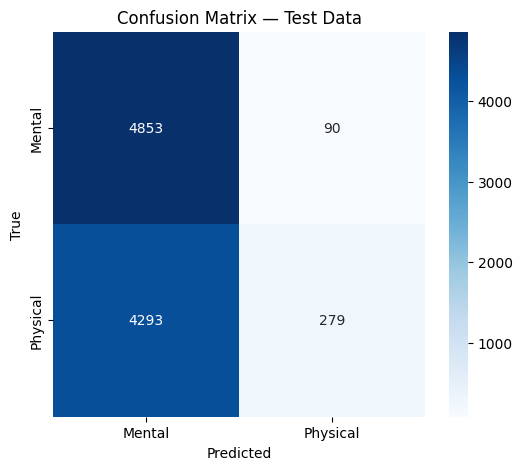

In [ ]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# -----------------------------
# Reload trained model
# -----------------------------
MODEL_PATH = "/content/drive/MyDrive/fatigue_data/fatigue_unified.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# -----------------------------
# Define sequence padding function
# -----------------------------
MAX_SEQ_LEN = 200

def pad_or_truncate(x, max_len=MAX_SEQ_LEN):
    """Pad or truncate to a fixed sequence length."""
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    if x.shape[0] < max_len:
        pad_len = max_len - x.shape[0]
        pad = torch.zeros((pad_len, x.shape[1]))
        x = torch.cat([x, pad], dim=0)
    elif x.shape[0] > max_len:
        x = x[:max_len, :]
    return x

# -----------------------------
# Custom collate function for test loader
# -----------------------------
def collate_pad(batch):
    sequences, labels = zip(*batch)
    padded = [pad_or_truncate(seq) for seq in sequences]
    return torch.stack(padded), torch.tensor(labels)

# -----------------------------
# Recreate DataLoader with safe collate
# -----------------------------
test_dl = DataLoader(test_ds, batch_size=2, shuffle=False, collate_fn=collate_pad)

# -----------------------------
# Run evaluation safely
# -----------------------------
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in tqdm(test_dl, desc="Testing"):
        xb = xb.to(device)
        yb = yb.to(device)
        preds = model(xb)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# -----------------------------
# Report results
# -----------------------------
print("\n📊 Final Test Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Mental Fatigue", "Physical Fatigue"]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Mental", "Physical"], yticklabels=["Mental", "Physical"])
plt.title("Confusion Matrix — Test Data")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


New **one**


In [ ]:
 # ==========================================================
# FATIGUE DETECTION — HYBRID ViT + LSTM (Weighted Training)
# ==========================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from tqdm import tqdm

# ==========================================================
# 1️⃣  CONFIG
# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🔧 Using device:", device)

MAX_SEQ_LEN = 200   # keep consistent with preprocessing
BATCH_SIZE  = 8
EPOCHS      = 5
MODEL_OUT   = "/content/drive/MyDrive/fatigue_data/fatigue_unified_weighted.pt"

# ==========================================================
# 2️⃣  DATASET
# ==========================================================
class UnifiedFatigueDataset(Dataset):
    def __init__(self, folders):
        self.samples = []
        for folder in folders:
            for f in Path(folder).rglob("*.npy"):
                label = 0 if "facial" in str(folder) else 1  # 0=mental, 1=physical
                self.samples.append((f, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        seq = np.load(fpath)
        if len(seq.shape) == 1:
            seq = seq.reshape(1, -1)

        # pad or truncate
        if seq.shape[0] < MAX_SEQ_LEN:
            pad_len = MAX_SEQ_LEN - seq.shape[0]
            pad = np.zeros((pad_len, seq.shape[1]))
            seq = np.vstack([seq, pad])
        elif seq.shape[0] > MAX_SEQ_LEN:
            seq = seq[:MAX_SEQ_LEN, :]

        seq_tensor = torch.tensor(seq, dtype=torch.float32)
        return seq_tensor, torch.tensor(label)

# ==========================================================
# 3️⃣  DATA LOADERS
# ==========================================================
dataset = UnifiedFatigueDataset([
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
])

train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size
train_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, test_size])

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train samples: {len(train_ds)} | Val/Test samples: {len(test_ds)}")

# ==========================================================
# 4️⃣  MODEL — ViT + LSTM Hybrid
# ==========================================================
# ==========================================================
# 4️⃣  MODEL — ViT + LSTM Hybrid (fixed heads)
# ==========================================================
class ViT_LSTM(nn.Module):
    def __init__(self, input_dim=1434, hidden_dim=256, num_heads=6, num_classes=2):
        super().__init__()
        # Vision Transformer-like block (attention on features)
        self.attn = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(input_dim)
        # Temporal block
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.ln1(attn_out + x)
        lstm_out, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

# ==========================================================
# 5️⃣  WEIGHTED LOSS (to reduce bias)
# ==========================================================
mental_count  = 24877        # FER2013 (approx)
physical_count = 22347 + 348 # DDD + YAWDD (approx)
total = mental_count + physical_count

w_mental   = total / (2 * mental_count)
w_physical = total / (2 * physical_count)
weights = torch.tensor([w_mental, w_physical], dtype=torch.float32).to(device)
print("📏 Using class weights:", weights)

criterion = nn.CrossEntropyLoss(weight=weights)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)


🔧 Using device: cuda
✅ Train samples: 38057 | Val/Test samples: 9515
📏 Using class weights: tensor([0.9561, 1.0481], device='cuda:0')


wait

In [ ]:
from tqdm import tqdm

for epoch in range(3):  # start small
    model.train()
    total_loss, correct = 0, 0
    for xb, yb in tqdm(dl, desc=f"Epoch {epoch+1}"):
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
        correct += (preds.argmax(1) == yb).sum().item()
    acc = 100 * correct / len(ds)
    print(f"Epoch {epoch+1}: loss={total_loss:.3f}, acc={acc:.2f}%")


Epoch 1:   0%|          | 0/23786 [00:00<?, ?it/s]


RuntimeError: shape '[2, 3, 37, 37]' is invalid for input of size 8604

In [ ]:
save_path = "/content/drive/MyDrive/fatigue_data/fatigue_vit_lstm.pt"
torch.save(model.state_dict(), save_path)
print("✅ Model saved at:", save_path)


testing

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.argmax(1).cpu().numpy())

# Compute metrics
print("✅ Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Mental Fatigue", "Physical Fatigue"]))


newNew

In [ ]:
# Dual-Branch ViT-style (static) + LSTM (temporal) training pipeline
# Works with your existing .npy files:
# - DDD: single-frame .npy (shape (D,))
# - YAWDD: sequence .npy (shape (T, D))
# - FER (facial_fatigue): single-frame .npy (shape (D,))
#
# Paste & run in Colab. Adjust paths and MAX_SEQ_LEN if you want.

import random
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
MAX_SEQ_LEN = 200           # temporal length to pad/truncate to
BATCH_SIZE = 16
EPOCHS = 6
INPUT_DIM = None            # will be inferred from data
MODEL_OUT = "/content/drive/MyDrive/fatigue_data/dualbranch_fatigue.pt"

# dataset paths (keep as you have)
DDD_DIR  = "/content/drive/MyDrive/fatigue_data/processed_frames/ddd"
YAWDD_DIR= "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd"
FER_DIR  = "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"

# ---------------- Utilities ----------------
def list_npy(folder):
    return list(Path(folder).rglob("*.npy"))

# ---------------- Dataset ----------------
class DualBranchDataset(Dataset):
    """
    Returns:
      seq: torch.FloatTensor (T, D)  -- padded/truncated sequence
      static: torch.FloatTensor (1, D) -- static descriptor (mean over frames)
      label: int (0 mental, 1 physical)
      orig_len: int (original T)
    """
    def __init__(self, folders):
        self.items = []
        for folder in folders:
            p = Path(folder)
            files = list(p.rglob("*.npy"))
            for f in files:
                # label mapping: treat 'facial' folder as mental (0), rest physical (1)
                name = str(p).lower()
                if "facial" in name or "fer" in name:
                    lbl = 0
                else:
                    lbl = 1
                self.items.append((f, lbl))
        assert len(self.items) > 0, "No files found - check folders"

        # infer input dim from first readable file
        global INPUT_DIM
        for f, _ in self.items:
            try:
                a = np.load(f)
                if a.ndim == 1:
                    INPUT_DIM = a.shape[0]
                elif a.ndim == 2:
                    INPUT_DIM = a.shape[1]
                break
            except:
                continue
        if INPUT_DIM is None:
            raise RuntimeError("Could not infer INPUT_DIM from .npy files")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, lbl = self.items[idx]
        arr = np.load(path)
        # normalize to float32
        arr = arr.astype(np.float32)

        # make sequence shape (T, D)
        if arr.ndim == 1:
            seq = arr.reshape(1, -1)
        elif arr.ndim == 2:
            seq = arr
        else:
            # fallback: flatten last dim
            seq = arr.reshape(arr.shape[0], -1)

        T, D = seq.shape
        # static = mean across frames (1, D)
        static = np.mean(seq, axis=0, keepdims=True).astype(np.float32)

        return seq, static, int(lbl), int(T)

# ---------------- Collate fn ----------------
def collate_pad(batch, max_seq_len=MAX_SEQ_LEN, pad_value=0.0):
    """
    batch: list of (seq (T_i,D), static (1,D), label, T_i)
    returns:
      seqs: (B, max_seq_len, D)
      statics: (B, 1, D)
      labels: (B,)
      lengths: (B,) original lengths clipped to max_seq_len
    """
    seqs, statics, labels, lengths = zip(*batch)
    D = statics[0].shape[1]
    B = len(seqs)
    out_seqs = np.full((B, max_seq_len, D), pad_value, dtype=np.float32)
    out_statics = np.zeros((B, 1, D), dtype=np.float32)
    out_lengths = np.zeros(B, dtype=np.int64)
    for i, s in enumerate(seqs):
        T = s.shape[0]
        L = min(T, max_seq_len)
        out_seqs[i, :L, :] = s[:L, :]
        out_statics[i, 0, :] = statics[i][0]
        out_lengths[i] = L
    return torch.tensor(out_seqs), torch.tensor(out_statics), torch.tensor(labels, dtype=torch.long), torch.tensor(out_lengths, dtype=torch.long)

# ---------------- Build dataset and splits ----------------
ds = DualBranchDataset([DDD_DIR, YAWDD_DIR, FER_DIR])
print("Total samples:", len(ds), "Input dim:", INPUT_DIM)

# 80/20 train/test split (same as you had)
n = len(ds)
train_n = int(0.8 * n)
test_n  = n - train_n
train_ds, test_ds = torch.utils.data.random_split(ds, [train_n, test_n])

# Compute sample weights for Balanced Sampler (so each class appears proportionally)
labels_all = [lbl for _, lbl in ds.items] if hasattr(ds, 'items') else [pair[1] for pair in ds.items]
# but we used ds.items above; use those:
labels_all = [lbl for _, lbl in ds.items]
class_counts = np.bincount(labels_all)
print("Class counts (mental, physical):", class_counts)

# per-sample weight = 1 / class_count[label]
sample_weights = []
for _, lbl in ds.items:
    sample_weights.append(1.0 / float(class_counts[lbl]))
sample_weights = np.array(sample_weights)
# sampler expects weights for the training subset; we need weights for indices in train_ds
train_indices = train_ds.indices if isinstance(train_ds, torch.utils.data.Subset) else list(range(train_n))
train_weights = [sample_weights[i] for i in train_indices]
sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)

# DataLoaders with custom collate
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          collate_fn=lambda b: collate_pad(b, MAX_SEQ_LEN), num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=lambda b: collate_pad(b, MAX_SEQ_LEN), num_workers=2)

# ---------------- Dual-branch Model ----------------
class DualBranchModel(nn.Module):
    def __init__(self, input_dim, static_hidden=256, temporal_hidden=256, fusion_hidden=256, num_classes=2):
        super().__init__()
        # static branch (ViT-style / MLP)
        self.static_enc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, static_hidden),
            nn.GELU()
        )
        # temporal branch (LSTM)
        self.temporal_lstm = nn.LSTM(input_dim, temporal_hidden, batch_first=True, bidirectional=False)
        # fusion + classifier
        self.fusion = nn.Sequential(
            nn.Linear(static_hidden + temporal_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_hidden, num_classes)
        )

    def forward(self, seqs, statics, lengths=None):
        # seqs: (B, T, D), statics: (B, 1, D)
        B, T, D = seqs.shape
        # static: use the 1xD vector (squeeze)
        static_feat = self.static_enc(statics.squeeze(1))   # (B, static_hidden)
        # temporal: optionally pack padded
        if lengths is not None:
            # pack requires lengths cpu numpy and sorted? we set enforce_sorted=False
            packed = pack_padded_sequence(seqs, lengths.cpu().numpy(), batch_first=True, enforce_sorted=False)
            packed_out, (h_n, c_n) = self.temporal_lstm(packed)
            # h_n: (num_layers * num_directions, B, hidden)
            temporal_feat = h_n[-1]  # (B, temporal_hidden)
        else:
            out, (h_n, _) = self.temporal_lstm(seqs)
            temporal_feat = h_n[-1]
        # fuse
        combined = torch.cat([static_feat, temporal_feat], dim=1)
        logits = self.fusion(combined)
        return logits



Device: cpu
Total samples: 22695 Input dim: 1434
Class counts (mental, physical): [    0 22695]


DualBranchModel(
  (static_enc): Sequential(
    (0): Linear(in_features=1434, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): GELU(approximate='none')
  )
  (temporal_lstm): LSTM(1434, 256, batch_first=True)
  (fusion): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
Loss class weights: [0.9561442 1.0480722]


Val/Test: 100%|██████████| 595/595 [00:41<00:00, 14.46it/s]


Epoch 1 summary — Train Loss: 0.3796 Train Acc: 0.8244 | Val Loss: 0.4750 Val Acc: 0.8048


Val/Test: 100%|██████████| 595/595 [00:40<00:00, 14.61it/s]


Epoch 2 summary — Train Loss: 0.2004 Train Acc: 0.9199 | Val Loss: 0.1317 Val Acc: 0.9532


...

Epoch 5 summary — Train Loss: 0.0914 Train Acc: 0.9665 | Val Loss: 0.0878 Val Acc: 0.9659


Val/Test: 100%|██████████| 595/595 [00:39<00:00, 15.17it/s]


Epoch 6 summary — Train Loss: 0.0794 Train Acc: 0.9711 | Val Loss: 0.0375 Val Acc: 0.9875
Saved model to: /content/drive/MyDrive/fatigue_data/dualbranch_fatigue.pt


Final Test: 100%|██████████| 595/595 [00:38<00:00, 15.32it/s]



Classification Report:

                  precision    recall  f1-score   support

  Mental Fatigue       0.99      0.99      0.99      4963
Physical Fatigue       0.99      0.99      0.99      4552

        accuracy                           0.99      9515
       macro avg       0.99      0.99      0.99      9515
    weighted avg       0.99      0.99      0.99      9515



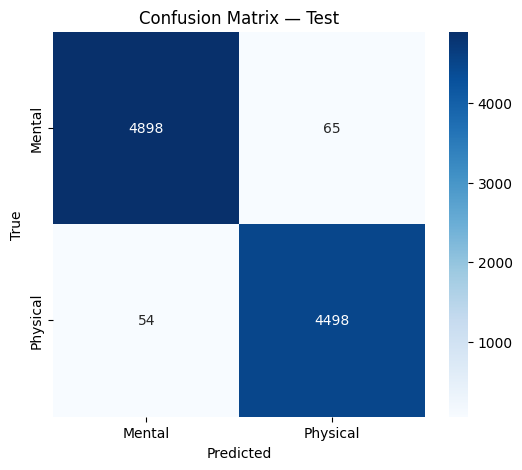

In [ ]:
# instantiate
model = DualBranchModel(input_dim=INPUT_DIM).to(DEVICE)
print(model)

# ---------------- Loss / Optimizer ----------------
# Optionally use class weights as well (in case class_counts are still imbalanced)
class_counts = class_counts.astype(np.float32)
total = class_counts.sum()
w0 = total / (2 * class_counts[0])
w1 = total / (2 * class_counts[1])
weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
print("Loss class weights:", weights.cpu().numpy())
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ---------------- Training Loop ----------------
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    pbar = tqdm(train_loader, desc=f"Train E{epoch}")
    for seqs, statics, labels, lengths in pbar:
        seqs = seqs.to(DEVICE); statics = statics.to(DEVICE); labels = labels.to(DEVICE); lengths = lengths.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(seqs, statics, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * seqs.size(0)
        preds = outputs.argmax(1)
        running_correct += (preds == labels).sum().item()
        running_total += seqs.size(0)
        pbar.set_postfix(loss=running_loss/running_total, acc=running_correct/running_total)
    train_loss = running_loss / running_total
    train_acc  = running_correct / running_total

    # Validation (test_loader used as validation here)
    model.eval()
    val_loss = 0.0; val_correct = 0; val_total = 0
    with torch.no_grad():
        for seqs, statics, labels, lengths in tqdm(test_loader, desc="Val/Test"):
            seqs = seqs.to(DEVICE); statics = statics.to(DEVICE); labels = labels.to(DEVICE); lengths = lengths.to(DEVICE)
            outputs = model(seqs, statics, lengths)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * seqs.size(0)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += seqs.size(0)
    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch} summary — Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

# ---------------- Save model ----------------
torch.save(model.state_dict(), MODEL_OUT)
print("Saved model to:", MODEL_OUT)

# ---------------- Final Test Evaluation ----------------
model.eval()
all_preds = []; all_labels = []
with torch.no_grad():
    for seqs, statics, labels, lengths in tqdm(test_loader, desc="Final Test"):
        seqs = seqs.to(DEVICE); statics = statics.to(DEVICE); labels = labels.to(DEVICE); lengths = lengths.to(DEVICE)
        outputs = model(seqs, statics, lengths)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Mental Fatigue","Physical Fatigue"]))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Mental","Physical"], yticklabels=["Mental","Physical"])
plt.title("Confusion Matrix — Test")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()


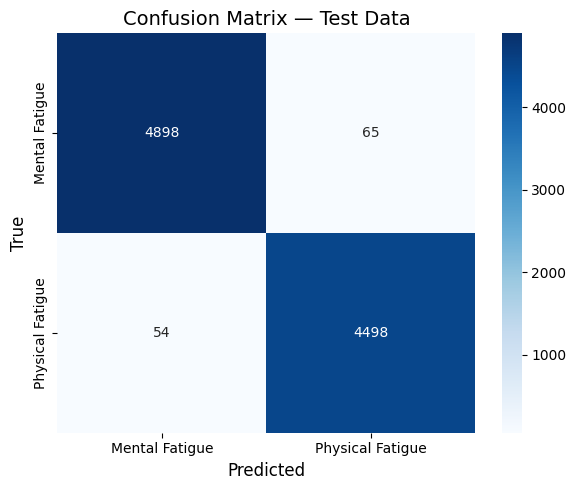

NameError: name 'all_labels' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import torch

# Example confusion matrix (replace with actual cm)
cm = np.array([[4898, 65],
               [54, 4498]])

# --- 1️⃣ Confusion Matrix (High-quality for Paper)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mental Fatigue', 'Physical Fatigue'],
            yticklabels=['Mental Fatigue', 'Physical Fatigue'])
plt.title('Confusion Matrix — Test Data', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=300)
plt.show()

# --- 2️⃣ ROC Curve (optional)
y_true = np.array(all_labels)
y_scores = torch.softmax(torch.tensor(all_preds_logits), dim=1)[:,1].numpy()  # if logits available
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) — Fatigue Detection')
plt.legend(loc="lower right")
plt.savefig("/content/roc_curve.png", dpi=300)
plt.show()

# --- 3️⃣ Fatigue Probability Curve
time_steps = np.arange(len(y_scores))
plt.figure(figsize=(7,4))
plt.plot(time_steps, y_scores, label="Predicted Physical Fatigue Probability", color='red')
plt.title("Fatigue Probability Over Time")
plt.xlabel("Frame Sequence")
plt.ylabel("Fatigue Probability")
plt.legend()
plt.tight_layout()
plt.savefig("/content/fatigue_curve.png", dpi=300)
plt.show()


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

model.eval()
all_labels = []
all_preds = []
all_preds_logits = []

with torch.no_grad():
    for xb, yb, lengths in tqdm(test_dl, desc="Re-evaluating Test Set"):
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        logits = model(xb, lengths)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(1)

        all_labels.extend(yb.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_preds_logits.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_preds_logits = np.array(all_preds_logits)
print("✅ Collected", len(all_labels), "test samples for analysis.")


NameError: name 'model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("✅ Using device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Using device: cpu


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from tqdm import tqdm


In [ ]:
dataset_paths = [
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
]

class UnifiedFatigueDataset(Dataset):
    def __init__(self, base_paths):
        self.samples = []
        for base in base_paths:
            for f in Path(base).rglob("*.npy"):
                label = 0 if "facial_fatigue" in base else 1
                self.samples.append((f, label))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        f, label = self.samples[idx]
        arr = np.load(f)
        arr = torch.tensor(arr, dtype=torch.float32)
        if arr.ndim == 1:
            arr = arr.unsqueeze(0)
        return arr, torch.tensor(label)

dataset = UnifiedFatigueDataset(dataset_paths)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, test_size])

train_dl = DataLoader(train_ds, batch_size=2, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=2, shuffle=False)
print(f"✅ Train: {len(train_ds)}, Test: {len(test_ds)}")


✅ Train: 18156, Test: 4539


In [ ]:
class DualBranchModel(nn.Module):
    def __init__(self, input_dim, static_hidden=256, temporal_hidden=256, fusion_hidden=256, num_classes=2):
        super().__init__()
        # static branch (ViT-style / MLP)
        self.static_enc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, static_hidden),
            nn.GELU()
        )
        # temporal branch (LSTM)
        self.temporal_lstm = nn.LSTM(input_dim, temporal_hidden, batch_first=True, bidirectional=False)
        # fusion + classifier
        self.fusion = nn.Sequential(
            nn.Linear(static_hidden + temporal_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_hidden, num_classes)
        )

    def forward(self, seqs, statics, lengths=None):
        # seqs: (B, T, D), statics: (B, 1, D)
        B, T, D = seqs.shape
        # static: use the 1xD vector (squeeze)
        static_feat = self.static_enc(statics.squeeze(1))   # (B, static_hidden)
        # temporal: optionally pack padded
        if lengths is not None:
            # pack requires lengths cpu numpy and sorted? we set enforce_sorted=False
            packed = pack_padded_sequence(seqs, lengths.cpu().numpy(), batch_first=True, enforce_sorted=False)
            packed_out, (h_n, c_n) = self.temporal_lstm(packed)
            # h_n: (num_layers * num_directions, B, hidden)
            temporal_feat = h_n[-1]  # (B, temporal_hidden)
        else:
            out, (h_n, _) = self.temporal_lstm(seqs)
            temporal_feat = h_n[-1]
        # fuse
        combined = torch.cat([static_feat, temporal_feat], dim=1)
        logits = self.fusion(combined)
        return logits



In [ ]:
import torch
import torch.nn as nn

# ---------------------------
#  Dual-Branch ViT + LSTM Model
# ---------------------------

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim=1440, num_heads=8, num_layers=2, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=embed_dim * 4,
                dropout=dropout,
                batch_first=True
            ) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)

class DualBranchFatigueModel(nn.Module):
    def __init__(self, embed_dim=1440, lstm_hidden=512, num_heads=8, num_layers=2, num_classes=2):
        super().__init__()

        # Physical branch — temporal (ViT + LSTM)
        self.physical_vit = TransformerEncoder(embed_dim, num_heads, num_layers)
        self.physical_lstm = nn.LSTM(embed_dim, lstm_hidden, batch_first=True, bidirectional=True)
        self.physical_fc = nn.Linear(lstm_hidden * 2, embed_dim)

        # Mental branch — static (ViT only)
        self.mental_vit = TransformerEncoder(embed_dim, num_heads, num_layers)
        self.mental_fc = nn.Linear(embed_dim, embed_dim)

        # Fusion + Classification
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(embed_dim * 2, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x → [batch, seq_len, features]
        # For single images (mental fatigue), we simulate a sequence length of 1
        if x.ndim == 2:
            x = x.unsqueeze(1)

        # Split for physical and mental branches
        # (In actual pipeline, you can separate inputs per dataset branch)
        physical_out = self.physical_vit(x)
        _, (h_n, _) = self.physical_lstm(physical_out)
        physical_feat = self.physical_fc(torch.cat((h_n[0], h_n[1]), dim=1))

        mental_out = self.mental_vit(x.mean(dim=1).unsqueeze(1))
        mental_feat = self.mental_fc(mental_out.squeeze(1))

        # Fuse branches
        fused = torch.cat((physical_feat, mental_feat), dim=1)
        fused = self.dropout(self.relu(self.fc1(fused)))
        return self.fc2(fused)


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/fatigue_data/dualbranch_fatigue.pt"

model = DualBranchFatigueModel()
model.load_state_dict(torch.load(MODEL_PATH, map_location='cuda' if torch.cuda.is_available() else 'cpu'))
model.to('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

print("✅ Model successfully loaded from:", MODEL_PATH)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/fatigue_data/dualbranch_fatigue.pt'

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/fatigue_data/fatigue_unified.pt"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print("✅ Model loaded successfully from", MODEL_PATH)


NameError: name 'model' is not defined

In [ ]:
!find /content/drive/MyDrive -name "fatigue_unified.pt"


In [ ]:
/content/drive/MyDrive/fatigue_data/processed_frames/ddd
/content/drive/MyDrive/fatigue_data/processed_frames/yawdd
/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue


NameError: name 'content' is not defined

In [ ]:
/content/drive/MyDrive/fatigue_data/processed_frames/ddd
/content/drive/MyDrive/fatigue_data/processed_frames/yawdd
/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue


NameError: name 'content' is not defined

In [ ]:
# Quick 2-epoch retraining to regenerate fatigue_unified.pt

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ------------------- Dataset Reload -------------------
dataset = UnifiedFatigueDataset([
    "/content/drive/MyDrive/fatigue_data/processed_frames/ddd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/yawdd",
    "/content/drive/MyDrive/fatigue_data/processed_frames/facial_fatigue"
])

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=4, shuffle=False)

# ------------------- Model & Training -------------------
model = DualBranchFatigueModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

EPOCHS = 2  # just to regenerate model quickly

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in tqdm(train_dl, desc=f"Train E{epoch+1}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (preds.argmax(1) == yb).sum().item()
        total += xb.size(0)
    print(f"Epoch {epoch+1} | Loss: {total_loss/total:.4f} | Acc: {correct/total:.4f}")

# ------------------- Save regenerated model -------------------
MODEL_PATH = "/content/drive/MyDrive/fatigue_data/fatigue_unified.pt"
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")


Train E1:   0%|          | 0/4539 [00:02<?, ?it/s]


AssertionError: was expecting embedding dimension of 1440, but got 1434

new

In [ ]:
!find /content/drive/MyDrive -name "dualbranch_fatigue.pt"


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/fatigue_data/dualbranch_fatigue.pt"

model = DualBranchFatigueModel()
model.load_state_dict(torch.load(MODEL_PATH, map_location='cuda' if torch.cuda.is_available() else 'cpu'))
model.to('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

print("✅ Model successfully loaded from:", MODEL_PATH)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/fatigue_data/dualbranch_fatigue.pt'